In [9]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [10]:
X = pd.read_csv('../../data/processed/normalized_best_features.csv', index_col=0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
df_engineered = pd.read_csv('../../data/processed/normalized_best_features.csv')
df_meta = pd.read_csv('../../data/processed/meta_best.csv')
df_with_clusters = df_meta.join(df_engineered)

In [12]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

gmm_final = GaussianMixture(
    n_components=5,
    covariance_type="full",
    random_state=42,
    n_init=10
)

cluster_labels = gmm_final.fit_predict(X_pca)
cluster_probs = gmm_final.predict_proba(X_pca)
df_with_clusters["role_cluster"] = cluster_labels

for k in range(gmm_final.n_components):
    df_with_clusters[f"cluster_{k}_prob"] = cluster_probs[:, k]

In [13]:
for c in sorted(df_with_clusters["role_cluster"].unique()):
    print(f"\n=== Cluster {c}: Top 10 by CA ===")
    display(
        df_with_clusters[df_with_clusters["role_cluster"] == c]
        [["Name","Club","CA","PA"]]
        .sort_values(by="CA", ascending=False)
        .head(10)
    )


=== Cluster 0: Top 10 by CA ===


,Name,Club,CA,PA
2,Joshua Kimmich,FC Bayern,174,183
20,David Alaba,R. Madrid,159,174
38,Sandro Tonali,Newcastle,157,171
136,Yves Bissouma,Tottenham,157,165
26,Koke,A. Madrid,157,162
115,Moisés Caicedo,Chelsea,156,185
90,Rodrigo Bentancur,Tottenham,156,164
33,Thomas Partey,Arsenal,155,162
17,Thomas Müller,FC Bayern,155,174
36,Guido Rodríguez,Real Hispalis,155,162



=== Cluster 1: Top 10 by CA ===


,Name,Club,CA,PA
0,Harry Kane,FC Bayern,184,185
9,Martin Ødegaard,Arsenal,173,180
5,Luka Modrić,R. Madrid,171,180
14,İlkay Gündoğan,Barcelona,167,167
15,Frenkie de Jong,Barcelona,165,181
27,Bruno Guimarães,Newcastle,165,170
10,Thiago,Liverpool,163,173
13,Pedri,Barcelona,162,175
28,Trent Alexander-Arnold,Liverpool,162,174
21,Hakan Çalhanoğlu,Inter,160,160



=== Cluster 2: Top 10 by CA ===


,Name,Club,CA,PA
6,Declan Rice,Arsenal,176,182
8,Eduardo Camavinga,R. Madrid,170,180
31,Reece James,Chelsea,161,170
16,Casemiro,Man UFC,157,170
18,Leon Goretzka,FC Bayern,157,170
24,Aurélien Tchouameni,R. Madrid,157,177
22,Adrien Rabiot,Juventus,156,159
173,Lisandro Martínez,Man UFC,155,165
77,João Palhinha,Fulham,155,164
82,Benjamin White,Arsenal,155,162



=== Cluster 3: Top 10 by CA ===


,Name,Club,CA,PA
1,Jude Bellingham,R. Madrid,177,188
11,Federico Valverde,R. Madrid,168,175
4,Nicolò Barella,Inter,161,169
34,Mason Mount,Man UFC,156,170
37,Gavi,Barcelona,154,187
133,John McGinn,Aston Villa,153,155
92,James Ward-Prowse,West Ham,150,155
138,Douglas Luiz,Aston Villa,149,158
75,Noussair Mazraoui,FC Bayern,149,155
126,Conor Gallagher,Chelsea,149,164



=== Cluster 4: Top 10 by CA ===


,Name,Club,CA,PA
7,Bruno Fernandes,Man UFC,171,174
3,Leroy Sané,FC Bayern,169,172
25,Christopher Nkunku,Chelsea,162,172
45,Dejan Kulusevski,Tottenham,160,171
35,Marco Asensio,Paris SG,159,163
49,James Maddison,Tottenham,159,163
12,Jamal Musiala,FC Bayern,158,185
52,Dani Olmo,RB Leipzig,155,162
91,Álex Grimaldo,Bayer 04,154,156
65,Julian Brandt,Borussia Dortmund,154,158


In [14]:
def summarize_clusters(df_k, feature_cols):
    print("\n=== Cluster sizes ===")
    print(df_k["cluster"].value_counts().sort_index())
    
    print("\n=== Age / CA / PA by cluster ===")
    print(df_k.groupby("cluster")[["Age","CA","PA"]].mean().round(2))
summarize_clusters(df_with_clusters.rename(columns={"role_cluster":"cluster"}), X.columns.tolist())


=== Cluster sizes ===
cluster
0    147
1     75
2    190
3    101
4    170
Name: count, dtype: int64

=== Age / CA / PA by cluster ===
           Age      CA      PA
cluster                       
0        25.63  135.65  149.73
1        26.05  141.09  154.41
2        26.72  134.69  145.07
3        23.98  132.87  147.43
4        25.12  136.95  151.47


In [15]:
def cluster_attribute_profiles(df_k, feature_cols):
    scaler_attr = StandardScaler()
    Z = scaler_attr.fit_transform(df_k[feature_cols].values)
    df_z = pd.DataFrame(Z, columns=feature_cols, index=df_k.index)
    df_z["cluster"] = df_k["cluster"].values

    cluster_means = df_z.groupby("cluster")[feature_cols].mean().round(3)
    return cluster_means

def print_top_attributes_per_cluster(cluster_means, top_n=8):
    for c in cluster_means.index:
        print(f"\n=== Cluster {c}: top {top_n} attributes (z-score) ===")
        s = cluster_means.loc[c].sort_values(ascending=False)
        print(s.head(top_n))
        print("\n--- lowest attributes ---")
        print(s.tail(top_n))

cluster_means = cluster_attribute_profiles(
    df_with_clusters.rename(columns={"role_cluster":"cluster"}),
    X.columns.tolist()
)
print_top_attributes_per_cluster(cluster_means, top_n=8)


=== Cluster 0: top 8 attributes (z-score) ===
Pos    0.523
Tck    0.450
Cmp    0.398
Pas    0.387
Dec    0.370
Mar    0.353
Cnt    0.327
Tea    0.250
Name: 0, dtype: float64

--- lowest attributes ---
Fre    -0.287
L Th   -0.292
Cor    -0.295
Fla    -0.324
Pac    -0.366
Dri    -0.367
Cro    -0.383
Fin    -0.435
Name: 0, dtype: float64

=== Cluster 1: top 8 attributes (z-score) ===
Pas    1.155
Vis    0.969
Fir    0.959
Dec    0.939
Tec    0.913
Cmp    0.856
Cro    0.568
Cor    0.541
Name: 1, dtype: float64

--- lowest attributes ---
Str     -0.485
Hea     -0.536
Det     -0.591
Nat.1   -0.605
Wor     -0.613
Pac     -0.675
Bra     -0.751
Agg     -0.814
Name: 1, dtype: float64

=== Cluster 2: top 8 attributes (z-score) ===
Mar    0.961
Tck    0.883
Bra    0.864
Hea    0.828
Str    0.813
Pos    0.768
Jum    0.694
Agg    0.672
Name: 2, dtype: float64

--- lowest attributes ---
Fre   -0.822
Dri   -0.825
Pas   -0.864
Cor   -0.884
Fla   -0.918
Vis   -0.923
Fir   -0.992
Tec   -1.069
Name: 2, d

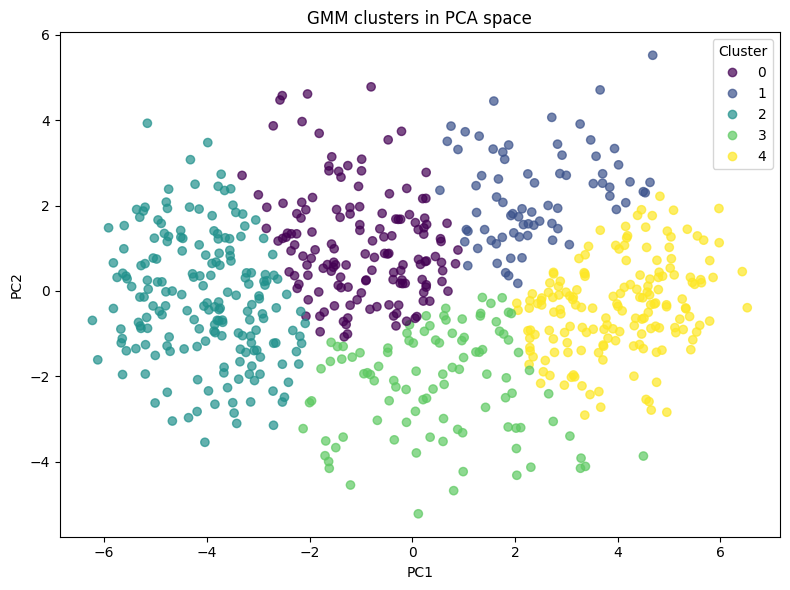

In [16]:
def plot_pca_scatter(X_pca, df_k):
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(
        X_pca[:,0],
        X_pca[:,1],
        c=df_k["cluster"],
        alpha=0.7
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("GMM clusters in PCA space")
    plt.legend(*scatter.legend_elements(), title="Cluster")
    plt.tight_layout()
    plt.show()
plot_pca_scatter(X_pca, df_with_clusters.rename(columns={"role_cluster":"cluster"}))